
## Viken KHATCHERIAN
## Formation AI Engineer
## Openclassrooms
## Projet 6 : initiez-vous au MLOps partie (1/2)
## Notebook 1 : 01_eda_data_prep.ipynb
### 1. Data loading
### 2. Data audit
### 3. Feature engineering
### 4. Aggregations tables secondaires
### 5. Merging
### 6. Final dataset check


## Bloc 1 : Load data

In [1559]:
# Chargement des premières données application_train et application_test
import pandas as pd
import numpy as np

DATA_PATH = "../data"

app_train = pd.read_csv(f"{DATA_PATH}/application_train.csv")
app_test = pd.read_csv(f"{DATA_PATH}/application_test.csv")

print("Train shape:", app_train.shape)
print("Test shape:", app_test.shape)

print("Train SK_ID_CURR unique:", app_train["SK_ID_CURR"].nunique())
print("Test SK_ID_CURR unique:", app_test["SK_ID_CURR"].nunique())

Train shape: (307511, 122)
Test shape: (48744, 121)
Train SK_ID_CURR unique: 307511
Test SK_ID_CURR unique: 48744


## Bloc 2 : Audit data

In [1560]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


In [1561]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,277796.676350,103169.547296,100001.000000,188557.750000,277549.000000,367555.500000,4.562500e+05
CNT_CHILDREN,48744.0,0.397054,0.709047,0.000000,0.000000,0.000000,1.000000,2.000000e+01
AMT_INCOME_TOTAL,48744.0,178431.805855,101522.591536,26941.500000,112500.000000,157500.000000,225000.000000,4.410000e+06
AMT_CREDIT,48744.0,516740.435561,365397.004174,45000.000000,260640.000000,450000.000000,675000.000000,2.245500e+06
AMT_ANNUITY,48720.0,29426.240209,16016.368315,2295.000000,17973.000000,26199.000000,37390.500000,1.805760e+05
AMT_GOODS_PRICE,48744.0,462618.840473,336710.215040,45000.000000,225000.000000,396000.000000,630000.000000,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,0.021226,0.014428,0.000253,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,48744.0,-16068.084605,4325.900393,-25195.000000,-19637.000000,-15785.000000,-12496.000000,-7.338000e+03
DAYS_EMPLOYED,48744.0,67485.366322,144348.507136,-17463.000000,-2910.000000,-1293.000000,-296.000000,3.652430e+05
DAYS_REGISTRATION,48744.0,-4967.652716,3552.612035,-23722.000000,-7459.250000,-4490.000000,-1901.000000,0.000000e+00


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


<Axes: >

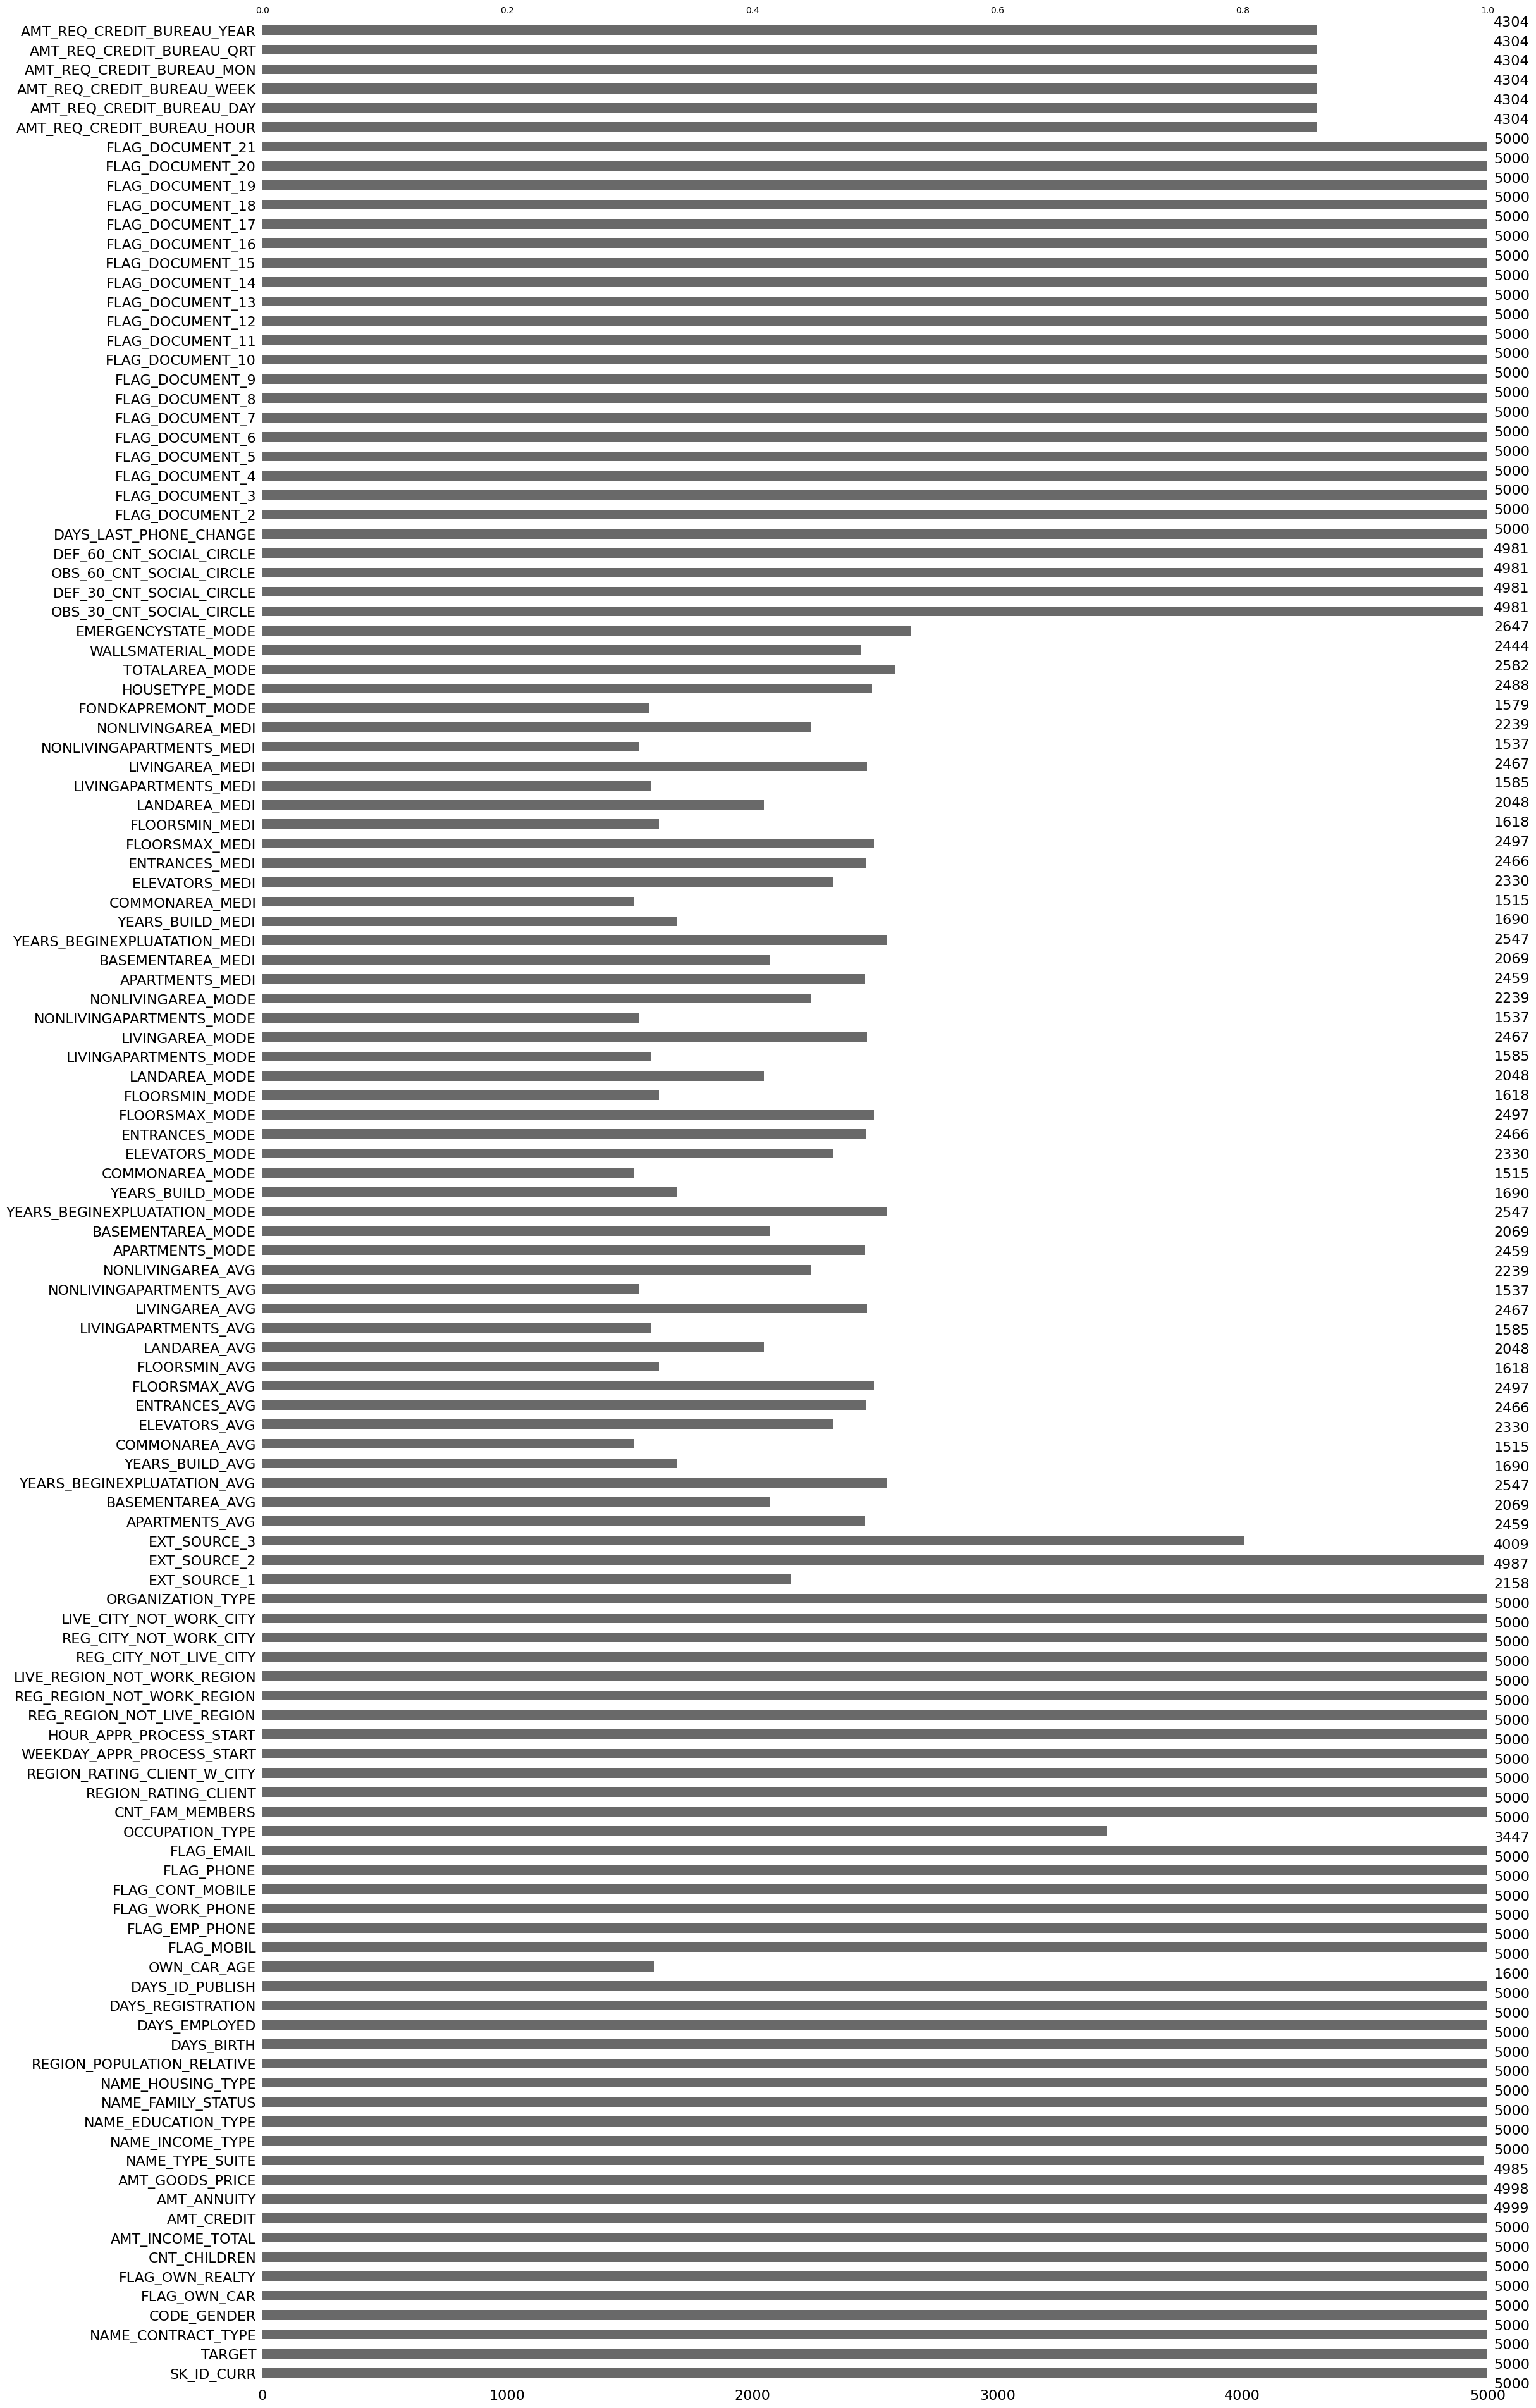

In [1562]:
print(app_train["TARGET"].value_counts(normalize=True))

import missingno as msno
msno.bar(app_train.sample(5000))

L'accuracy sera une métrique trompeuse. 
Pour la partie machine learning il faudra au minimum : 
- recall
- AUC
- F1-score

Et on inclura:
- class-weight="balanced"
- StratifierKFold

## Bloc 3 : Feature engineering 

définition CREDIT_INCOME_RATIO = combien de fois le crédit représente le revenu annuel du client
| Ratio | Lecture |
|------|---------|
| < 1  | crédit faible vs revenu (safe) |
| 1–3  | normal |
| 3–5  | risqué |
| > 5  | très risqué |

Le risque de défaut augmente quand:
- l'endettement relatif est élevé
- le client est "over-leveraged"

définition ANNUITY_INCOME_RATIO = part du revenu utilisée pour rembourser chaque année

| Ratio | Lecture |
|------|---------|
| < 0.1 | très confortable |
| 0.1–0.2 | normal |
| 0.2–0.4 | tension financière |
| > 0.5 | stress financier élevé |

Ce ratio approxime:
- capacité de remboursement mensuelle/ annuelle
- pression financière du client

Peut-être souvent plus prédictif que le revenu seul.


In [1563]:
import seaborn as sns
import matplotlib.pyplot as plt

def base_features(df):
    df = df.copy()

    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

    return df


app_train = base_features(app_train)
app_test = base_features(app_test)

In [1564]:
app_train[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"]].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
count,307511.000000,307499.000000
mean,3.957570,0.180930
std,2.689728,0.094574
min,0.004808,0.000224
25%,2.018667,0.114782
50%,3.265067,0.162833
75%,5.159880,0.229067
max,84.736842,1.875965


In [1565]:
ratio_cols = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO"
]

import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(df, col, dataset_name):
    plt.figure(figsize=(8,5))

    sns.histplot(df[col], bins=50, kde=True)

    plt.title(f"{dataset_name} - Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()


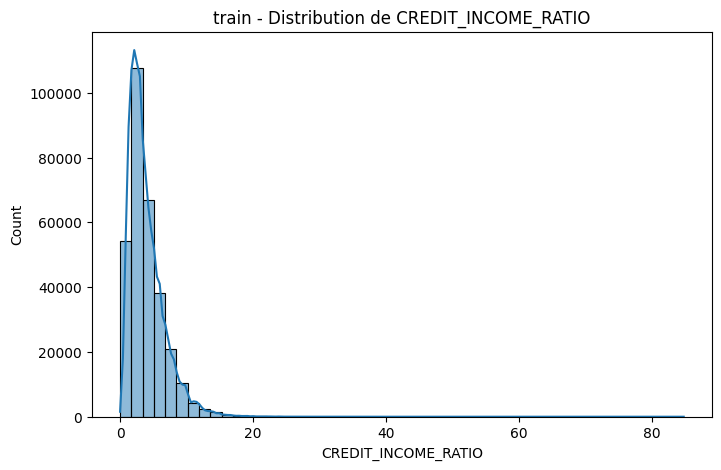

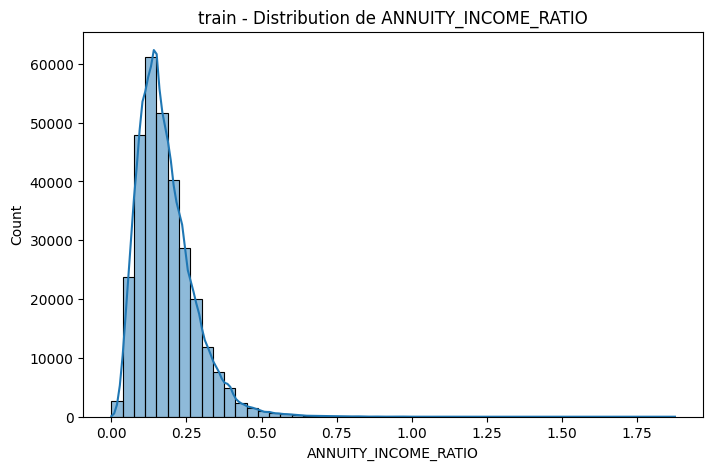

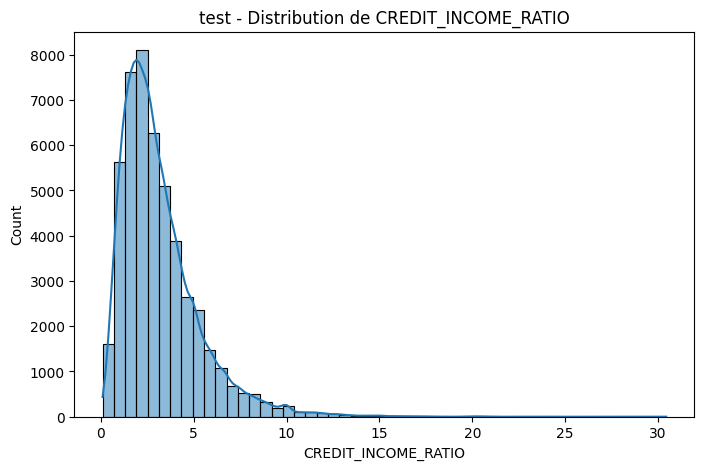

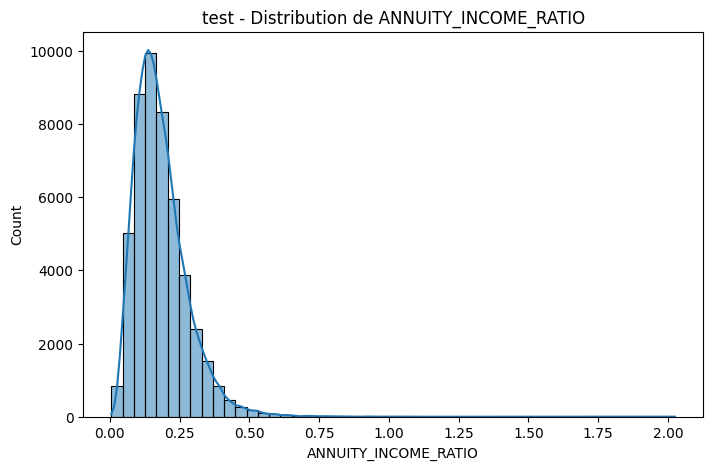

In [1566]:
for col in ratio_cols:
    plot_distribution(app_train, col, "train")

for col in ratio_cols:
    plot_distribution(app_test, col, "test")
                    


Analyse de CREDIT_INCOME_RATIO

Standards bancaires pour credit_income_ratio
| Zone | Lecture |
|------|---------|
| 0–2  | solvable confortable |
| 2–5  | standard crédit bancaire |
| >10  | client très risqué |

Distribution très allogée à droite (des clients très risqués tirent la moyenne vers le haut)

Valeur extrême = 84 peut être un possible outlier 

Analyse de ANNUITY_INCOME_RATIO
| Ratio | Interprétation |
|------|----------------|
| < 0.2 | sain |
| 0.2–0.4 | attention |
| > 0.5 | stress financier |
| > 1 | incohérence / très risqué |

Certains clients remboursent plus que leur revenu annuel. Erreur de données ou revenus sous-déclarés probables.





In [1567]:
# correction de l'anomalie DAYS_EMPLOYED = 365243
def fix_employment(df):
    df = df.copy()
    
    df["DAYS_EMPLOYED_ANOM"] = df["DAYS_EMPLOYED"] == 365243
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    
    return df

In [1568]:
app_train = fix_employment(app_train)
app_test = fix_employment(app_test)

In [1569]:
# Features métiers supplémentaires
# Age client (maturité financière)
app_train["AGE_YEARS"] = app_train["DAYS_BIRTH"] / -365
app_test["AGE_YEARS"] = app_test["DAYS_BIRTH"] / -365

In [1570]:
# Employement_years (maturité professionnelle)
app_train["EMPLOYMENT_YEARS"] = app_train["DAYS_EMPLOYED"] / -365
app_test["EMPLOYMENT_YEARS"] = app_test["DAYS_EMPLOYED"] / -365

In [1571]:
# Nombre de crédits actifs potentiels (plus la famille est grande plus il y a de pression financière)
app_train["INCOME_PER_PERSON"] = app_train["AMT_INCOME_TOTAL"] / (1 + app_train["CNT_FAM_MEMBERS"])
app_test["INCOME_PER_PERSON"] = app_test["AMT_INCOME_TOTAL"] / (1 + app_test["CNT_FAM_MEMBERS"])

In [1572]:
# Contrôle présence valeurs infinies
print("Train")
print(np.isinf(app_train[ratio_cols]).sum())

print("\nTest")
print(np.isinf(app_test[ratio_cols]).sum())

Train
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
dtype: int64

Test
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
dtype: int64


In [1573]:
# Contrôle présence NaN après features
print("Train")
print(app_train[ratio_cols].isnull().sum())

print("\nTest")
print(app_test[ratio_cols].isnull().sum())

Train
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    12
dtype: int64

Test
CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    24
dtype: int64


In [1574]:
# remplacer les valeurs maquantes par la médiane
app_train["ANNUITY_INCOME_RATIO"] = app_train["ANNUITY_INCOME_RATIO"].fillna(app_train["ANNUITY_INCOME_RATIO"].median())
app_test["ANNUITY_INCOME_RATIO"] = app_test["ANNUITY_INCOME_RATIO"].fillna(app_test["ANNUITY_INCOME_RATIO"].median())

In [1575]:
app_train[["CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,84.736842
ANNUITY_INCOME_RATIO,307511.0,0.180929,0.094572,0.000224,0.114785,0.162833,0.229064,1.875965


In [1576]:
app_test[["CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,48744.0,3.167544,2.137173,0.09250,1.695695,2.666143,4.0296,30.445000
ANNUITY_INCOME_RATIO,48744.0,0.182975,0.095456,0.00573,0.116397,0.165923,0.2298,2.024714


In [1577]:
app_train.shape, app_test.shape

((307511, 128), (48744, 127))

In [1578]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 128 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [1579]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 127 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [1580]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "DAYS_EMPLOYED_ANOM",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "INCOME_PER_PERSON"
]

app_train[new_features].isnull().sum()

CREDIT_INCOME_RATIO         0
ANNUITY_INCOME_RATIO        0
DAYS_EMPLOYED_ANOM          0
AGE_YEARS                   0
EMPLOYMENT_YEARS        55374
INCOME_PER_PERSON           2
dtype: int64

In [1581]:
app_test[new_features].isnull().sum()

CREDIT_INCOME_RATIO        0
ANNUITY_INCOME_RATIO       0
DAYS_EMPLOYED_ANOM         0
AGE_YEARS                  0
EMPLOYMENT_YEARS        9274
INCOME_PER_PERSON          0
dtype: int64

In [1582]:
import numpy as np

app_train[new_features].select_dtypes(include=["float64"]).apply(
    lambda col: np.isinf(col).sum()
)

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
AGE_YEARS               0
EMPLOYMENT_YEARS        0
INCOME_PER_PERSON       0
dtype: int64

In [1583]:
import numpy as np

app_test[new_features].select_dtypes(include=["float64"]).apply(
    lambda col: np.isinf(col).sum()
)

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
AGE_YEARS               0
EMPLOYMENT_YEARS        0
INCOME_PER_PERSON       0
dtype: int64

In [1584]:
app_train[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307511.0,0.180929,0.094572,0.000224,0.114785,0.162833,0.229064,1.875965e+00
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,-0.000000,2.101370,4.515068,8.698630,4.907397e+01
INCOME_PER_PERSON,307509.0,57482.254719,65851.657720,2647.058824,33750.000000,49500.000000,67500.000000,2.925000e+07


In [1585]:
app_test[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,48744.0,3.167544,2.137173,0.09250,1.695695,2.666143,4.029600,3.044500e+01
ANNUITY_INCOME_RATIO,48744.0,0.182975,0.095456,0.00573,0.116397,0.165923,0.229800,2.024714e+00
AGE_YEARS,48744.0,44.022150,11.851782,20.10411,34.235616,43.246575,53.800000,6.902740e+01
EMPLOYMENT_YEARS,39470.0,6.785586,6.323189,0.00274,2.358904,4.835616,9.119863,4.784384e+01
INCOME_PER_PERSON,48744.0,60715.182779,38903.141377,4875.00000,37500.000000,52500.000000,75000.000000,2.205000e+06


In [1586]:
# Valeurs nulles pour income per person
app_train.loc[
    app_train["INCOME_PER_PERSON"].isna(),
    ["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"]
]

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS
41982,450000.0,NaN
187348,202500.0,NaN


In [1587]:
app_train.loc[
    app_train["CNT_FAM_MEMBERS"].isna(),
    [
        "SK_ID_CURR",
        "AMT_INCOME_TOTAL",
        "CNT_FAM_MEMBERS",
        "INCOME_PER_PERSON"
    ]
]

,SK_ID_CURR,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,INCOME_PER_PERSON
41982,148605,450000.0,NaN,NaN
187348,317181,202500.0,NaN,NaN


In [1588]:
median_family = app_train["CNT_FAM_MEMBERS"].median()

print("Médiane CNT_FAM_MEMBERS :", median_family)

Médiane CNT_FAM_MEMBERS : 2.0


In [1589]:
app_train["CNT_FAM_MEMBERS"] = (
    app_train["CNT_FAM_MEMBERS"]
    .fillna(median_family)
)

In [1590]:
print(
    "Train NaN :",
    app_train["CNT_FAM_MEMBERS"].isna().sum()
)

Train NaN : 0


In [1591]:
print(
    "Test NaN :",
    app_test["CNT_FAM_MEMBERS"].isna().sum()
)

Test NaN : 0


In [1592]:
app_train["INCOME_PER_PERSON"] = (
    app_train["AMT_INCOME_TOTAL"]
    / app_train["CNT_FAM_MEMBERS"]
)

app_test["INCOME_PER_PERSON"] = (
    app_test["AMT_INCOME_TOTAL"]
    / app_test["CNT_FAM_MEMBERS"]
)

In [1593]:
app_train[
    ["AMT_INCOME_TOTAL",
     "CNT_FAM_MEMBERS",
     "INCOME_PER_PERSON"]
].sort_values(
    by="INCOME_PER_PERSON",
    ascending=False
).head(10)

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,INCOME_PER_PERSON
12840,117000000.0,3.0,39000000.0
246858,13500000.0,2.0,6750000.0
203693,18000090.0,4.0,4500022.5
77768,9000000.0,2.0,4500000.0
204564,4500000.0,1.0,4500000.0
103006,4500000.0,1.0,4500000.0
284311,3600000.0,1.0,3600000.0
131127,6750000.0,2.0,3375000.0
158338,2250000.0,1.0,2250000.0
206814,2250000.0,1.0,2250000.0


In [1594]:
print(
    "Train INCOME_PER_PERSON NaN :",
    app_train["INCOME_PER_PERSON"].isna().sum()
)

print(
    "Test INCOME_PER_PERSON NaN :",
    app_test["INCOME_PER_PERSON"].isna().sum()
)

Train INCOME_PER_PERSON NaN : 0
Test INCOME_PER_PERSON NaN : 0


Deux observations présentaient une valeur manquante pour CNT_FAM_MEMBERS. Une imputation par la médiane calculée sur le jeu d'entraînement a été réalisée afin de conserver les observations. La feature dérivée INCOME_PER_PERSON a ensuite été recalculée. Cette approche évite la suppression de données tout en limitant l'impact sur la distribution de la variable.

In [1595]:
# Vérification des clés de jointure
for df_name, df in {
    "train": app_train,
    "test": app_test
}.items():

    print(f"\n{df_name}")

    print("SK_ID_CURR unique :",
          df["SK_ID_CURR"].nunique())

    print("Lignes :",
          len(df))

    print("Doublons :",
          df["SK_ID_CURR"].duplicated().sum())



train
SK_ID_CURR unique : 307511
Lignes : 307511
Doublons : 0

test
SK_ID_CURR unique : 48744
Lignes : 48744
Doublons : 0


In [1596]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 128 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [1597]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 127 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

# Bloc 4 : Aggregations tables secondaires

In [1598]:
# tables bureau.csv et bureau_balance.csv
bureau = pd.read_csv(f"{DATA_PATH}/bureau.csv")
bureau_balance = pd.read_csv(f"{DATA_PATH}/bureau_balance.csv")

In [1599]:
bureau.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [1600]:
bureau_balance.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [1601]:
bureau_balance = pd.read_csv(DATA_PATH + "/bureau_balance.csv")

bureau_balance["HAS_LATE"] = bureau_balance["STATUS"].isin(
    ["1", "2", "3", "4", "5"]
).astype(int)

bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE": ["min", "max", "count"],
    "HAS_LATE": "max"
})

bb_agg.columns = ["_".join(col) for col in bb_agg.columns]
bb_agg = bb_agg.reset_index()

In [1602]:
bureau = pd.read_csv(DATA_PATH + "/bureau.csv")

bureau_bb = bureau.merge(
    bb_agg,
    on="SK_ID_BUREAU",
    how="left"
)

In [1603]:
bureau_final = bureau_bb.groupby("SK_ID_CURR").agg({
    "DAYS_CREDIT": ["min", "max", "mean"],
    "CREDIT_DAY_OVERDUE": "max",
    "AMT_CREDIT_SUM": "sum",
    "AMT_CREDIT_SUM_DEBT": "sum",
    "MONTHS_BALANCE_count": "mean",
    "MONTHS_BALANCE_min": "min",
    "MONTHS_BALANCE_max": "max",
    "HAS_LATE_max": "max"
})

In [1604]:
bureau_final.columns = [
    "_".join(col).replace("__", "_")
    for col in bureau_final.columns
]

bureau_final = bureau_final.reset_index()

In [1605]:
print(bureau_final.columns)
print(bureau_final.shape)

Index(['SK_ID_CURR', 'DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_mean',
       'CREDIT_DAY_OVERDUE_max', 'AMT_CREDIT_SUM_sum',
       'AMT_CREDIT_SUM_DEBT_sum', 'MONTHS_BALANCE_count_mean',
       'MONTHS_BALANCE_min_min', 'MONTHS_BALANCE_max_max', 'HAS_LATE_max_max'],
      dtype='object')
(305811, 11)


In [1606]:
app_train = app_train.merge(bureau_final, on="SK_ID_CURR", how="left")
app_test  = app_test.merge(bureau_final, on="SK_ID_CURR", how="left")

In [1607]:
print(app_train.shape)
print(app_test.shape)

(307511, 138)
(48744, 137)


In [1608]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 138 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [1609]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 137 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [1610]:
app_train.columns.duplicated().sum()

np.int64(0)

In [1611]:
app_train["SK_ID_CURR"].isna().sum()

np.int64(0)

In [1612]:
app_train.shape

(307511, 138)

In [1613]:
app_test.columns.duplicated().sum()

np.int64(0)

In [1614]:
app_test["SK_ID_CURR"].isna().sum()

np.int64(0)

In [1615]:
app_test.shape

(48744, 137)

In [1616]:
# table previous_application.csv
prev = pd.read_csv(f"{DATA_PATH}/previous_application.csv")

In [1617]:
prev.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,1670214.0,1.923089e+06,532597.958696,1.000001e+06,1.461857e+06,1.923110e+06,2.384280e+06,2845382.000
SK_ID_CURR,1670214.0,2.783572e+05,102814.823849,1.000010e+05,1.893290e+05,2.787145e+05,3.675140e+05,456255.000
AMT_ANNUITY,1297979.0,1.595512e+04,14782.137335,0.000000e+00,6.321780e+03,1.125000e+04,2.065842e+04,418058.145
AMT_APPLICATION,1670214.0,1.752339e+05,292779.762386,0.000000e+00,1.872000e+04,7.104600e+04,1.803600e+05,6905160.000
AMT_CREDIT,1670213.0,1.961140e+05,318574.616547,0.000000e+00,2.416050e+04,8.054100e+04,2.164185e+05,6905160.000
AMT_DOWN_PAYMENT,774370.0,6.697402e+03,20921.495410,-9.000000e-01,0.000000e+00,1.638000e+03,7.740000e+03,3060045.000
AMT_GOODS_PRICE,1284699.0,2.278473e+05,315396.557937,0.000000e+00,5.084100e+04,1.123200e+05,2.340000e+05,6905160.000
HOUR_APPR_PROCESS_START,1670214.0,1.248418e+01,3.334028,0.000000e+00,1.000000e+01,1.200000e+01,1.500000e+01,23.000
NFLAG_LAST_APPL_IN_DAY,1670214.0,9.964675e-01,0.059330,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000
RATE_DOWN_PAYMENT,774370.0,7.963682e-02,0.107823,-1.497876e-05,0.000000e+00,5.160508e-02,1.089091e-01,1.000


In [1618]:
prev["DAYS_FIRST_DRAWING"] = prev["DAYS_FIRST_DRAWING"].replace(365243, np.nan)
prev["DAYS_FIRST_DUE"] = prev["DAYS_FIRST_DUE"].replace(365243, np.nan)
prev["DAYS_LAST_DUE"] = prev["DAYS_LAST_DUE"].replace(365243, np.nan)
prev["DAYS_TERMINATION"] = prev["DAYS_TERMINATION"].replace(365243, np.nan)

In [1619]:
prev["SELLERPLACE_AREA"] = prev["SELLERPLACE_AREA"].clip(upper=10000)

In [1620]:
prev["RATE_INTEREST_MEAN"] = prev[
    ["RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"]
].mean(axis=1)

prev["RATE_INTEREST_IS_MISSING"] = prev[
    "RATE_INTEREST_PRIMARY"
].isna().astype(int)

In [1621]:
prev["AMT_DOWN_PAYMENT"] = prev["AMT_DOWN_PAYMENT"].clip(lower=0)

In [1622]:
# ratio montant demandé / montant accordé
prev["APP_CREDIT_RATIO"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]

# montant non payé upfront
prev["DOWNPAYMENT_RATIO"] = prev["AMT_DOWN_PAYMENT"] / (prev["AMT_APPLICATION"] + 1)

In [1623]:
prev_agg = prev.groupby("SK_ID_CURR").agg({
    "AMT_ANNUITY": ["mean"],
    "AMT_APPLICATION": ["sum", "mean"],
    "AMT_CREDIT": ["sum", "mean"],
    "AMT_DOWN_PAYMENT": ["sum"],
    "CNT_PAYMENT": ["mean"],
    "DAYS_DECISION": ["min", "max", "mean"],
    "APP_CREDIT_RATIO": ["mean"],
    "DOWNPAYMENT_RATIO": ["mean"]
})

In [1624]:
prev_agg.columns = [
    "_".join(col).strip() for col in prev_agg.columns
]

prev_agg = prev_agg.reset_index()

In [1625]:
print(prev_agg.shape)
print(prev_agg.columns)

(338857, 13)
Index(['SK_ID_CURR', 'AMT_ANNUITY_mean', 'AMT_APPLICATION_sum',
       'AMT_APPLICATION_mean', 'AMT_CREDIT_sum', 'AMT_CREDIT_mean',
       'AMT_DOWN_PAYMENT_sum', 'CNT_PAYMENT_mean', 'DAYS_DECISION_min',
       'DAYS_DECISION_max', 'DAYS_DECISION_mean', 'APP_CREDIT_RATIO_mean',
       'DOWNPAYMENT_RATIO_mean'],
      dtype='object')


In [1626]:
app_train = app_train.merge(prev_agg, on="SK_ID_CURR", how="left")
app_test = app_test.merge(prev_agg, on="SK_ID_CURR", how="left")

In [1627]:
print(app_train.shape)
print(app_test.shape)

(307511, 150)
(48744, 149)


In [1628]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 150 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [1629]:
app_train.columns.duplicated().sum()

np.int64(0)

In [1630]:
app_train["SK_ID_CURR"].isna().sum()

np.int64(0)

In [1631]:
app_train.describe().T

/mnt/projects/ai_engineer_projects/P06/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.687979e+05,2.371231e+05,2.565000e+04,112500.000000,147150.000000,2.025000e+05,1.170000e+08
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252137.0,-2.384169e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,0.000000e+00


In [1632]:
# Remplacer inf par NaN (très important)
app_train.replace([np.inf, -np.inf], np.nan, inplace=True)
app_train['DAYS_EMPLOYED_ANOM'] = (app_train['DAYS_EMPLOYED'] == 0).astype(int)

app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(0, np.nan)

for col in ['AMT_INCOME_TOTAL', 'INCOME_PER_PERSON']:
    app_train[col] = app_train[col].clip(
        lower=0,
        upper=app_train[col].quantile(0.999)
    )

app_train['APP_CREDIT_RATIO_mean'] = (
    app_train['AMT_APPLICATION_mean'] / app_train['AMT_CREDIT_mean']
)

app_train.replace([np.inf, -np.inf], np.nan, inplace=True)

def safe_div(a, b):
    return np.where(b == 0, np.nan, a / b)

app_train['CREDIT_INCOME_RATIO'] = safe_div(
    app_train['AMT_CREDIT'],
    app_train['AMT_INCOME_TOTAL']
)



In [1633]:
app_train.isna().sum().sort_values(ascending=False).head(20)

MONTHS_BALANCE_max_max       215280
HAS_LATE_max_max             215280
MONTHS_BALANCE_count_mean    215280
MONTHS_BALANCE_min_min       215280
COMMONAREA_MODE              214865
COMMONAREA_AVG               214865
COMMONAREA_MEDI              214865
NONLIVINGAPARTMENTS_MODE     213514
NONLIVINGAPARTMENTS_MEDI     213514
NONLIVINGAPARTMENTS_AVG      213514
FONDKAPREMONT_MODE           210295
LIVINGAPARTMENTS_MEDI        210199
LIVINGAPARTMENTS_MODE        210199
LIVINGAPARTMENTS_AVG         210199
FLOORSMIN_AVG                208642
FLOORSMIN_MEDI               208642
FLOORSMIN_MODE               208642
YEARS_BUILD_MODE             204488
YEARS_BUILD_MEDI             204488
YEARS_BUILD_AVG              204488
dtype: int64

In [1634]:
np.isinf(app_train.select_dtypes(include=[np.number])).sum().sum()

np.int64(0)

In [1635]:
app_train['AMT_INCOME_TOTAL_LOG'] = np.log1p(app_train['AMT_INCOME_TOTAL'])
app_train['AMT_CREDIT_LOG'] = np.log1p(app_train['AMT_CREDIT'])

In [1636]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 152 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [1637]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [1638]:
app_test.columns.duplicated().sum()

np.int64(0)

In [1639]:
app_test["SK_ID_CURR"].isna().sum()

np.int64(0)

In [1640]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 149 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [1641]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,100001.000000,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.784318e+05,1.015226e+05,26941.500000,112500.000000,1.575000e+05,2.250000e+05,4.410000e+06
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,45000.000000,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2295.000000,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,45000.000000,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,0.000253,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-25195.000000,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-17463.000000,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-23722.000000,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [1642]:
# 1
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2
app_test['DAYS_EMPLOYED_ANOM'] = (
    app_test['DAYS_EMPLOYED'] == 0
).astype(int)

app_test['DAYS_EMPLOYED'] = (
    app_test['DAYS_EMPLOYED'].replace(0, np.nan)
)

train_income_cap = app_train['AMT_INCOME_TOTAL'].quantile(0.999)
train_income_pp_cap = app_train['INCOME_PER_PERSON'].quantile(0.999)

# 3 (avec seuils train)
for col, cap in {
    'AMT_INCOME_TOTAL': train_income_cap,
    'INCOME_PER_PERSON': train_income_pp_cap
}.items():
    app_test[col] = app_test[col].clip(
        lower=0,
        upper=cap
    )

# 4
app_test['APP_CREDIT_RATIO_mean'] = safe_div(
    app_test['AMT_APPLICATION_mean'],
    app_test['AMT_CREDIT_mean']
)

# 5
app_test['CREDIT_INCOME_RATIO'] = safe_div(
    app_test['AMT_CREDIT'],
    app_test['AMT_INCOME_TOTAL']
)

# 6
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [1643]:
app_test['AMT_INCOME_TOTAL_LOG'] = np.log1p(
    app_test['AMT_INCOME_TOTAL']
)

app_test['AMT_CREDIT_LOG'] = np.log1p(
    app_test['AMT_CREDIT']
)

In [1644]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 151 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    NAME_CONTRACT_TYPE            object 
 2    CODE_GENDER                   object 
 3    FLAG_OWN_CAR                  object 
 4    FLAG_OWN_REALTY               object 
 5    CNT_CHILDREN                  int64  
 6    AMT_INCOME_TOTAL              float64
 7    AMT_CREDIT                    float64
 8    AMT_ANNUITY                   float64
 9    AMT_GOODS_PRICE               float64
 10   NAME_TYPE_SUITE               object 
 11   NAME_INCOME_TYPE              object 
 12   NAME_EDUCATION_TYPE           object 
 13   NAME_FAMILY_STATUS            object 
 14   NAME_HOUSING_TYPE             object 
 15   REGION_POPULATION_RELATIVE    float64
 16   DAYS_BIRTH                    int64  
 17   DAYS_EMPLOYED                 float64
 18   DAYS

In [1645]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,100001.000000,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,26941.500000,112500.000000,1.575000e+05,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,45000.000000,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2295.000000,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,45000.000000,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,0.000253,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-25195.000000,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-17463.000000,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-23722.000000,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [1646]:
(app_test['DAYS_EMPLOYED'] == 365243).sum()
(app_train['DAYS_EMPLOYED'] == 365243).sum()

np.int64(0)

In [1647]:
app_test['APP_CREDIT_RATIO_mean'].describe([0.99, 0.995, 0.999])

count    47775.000000
mean         0.943346
std          0.181764
min          0.000000
50%          0.950832
99%          1.428571
99.5%        1.601954
99.9%        2.000000
max         10.000000
Name: APP_CREDIT_RATIO_mean, dtype: float64

In [1648]:
app_test.isna().sum().sort_values(ascending=False).head(20)

COMMONAREA_MEDI             33495
COMMONAREA_MODE             33495
COMMONAREA_AVG              33495
NONLIVINGAPARTMENTS_MODE    33347
NONLIVINGAPARTMENTS_AVG     33347
NONLIVINGAPARTMENTS_MEDI    33347
FONDKAPREMONT_MODE          32797
LIVINGAPARTMENTS_AVG        32780
LIVINGAPARTMENTS_MODE       32780
LIVINGAPARTMENTS_MEDI       32780
FLOORSMIN_AVG               32466
FLOORSMIN_MODE              32466
FLOORSMIN_MEDI              32466
OWN_CAR_AGE                 32312
YEARS_BUILD_MEDI            31818
YEARS_BUILD_AVG             31818
YEARS_BUILD_MODE            31818
LANDAREA_MODE               28254
LANDAREA_AVG                28254
LANDAREA_MEDI               28254
dtype: int64

In [1649]:
np.isinf(app_test.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [1650]:
app_train.shape

(307511, 152)

In [1651]:
app_test.shape

(48744, 151)

In [1652]:
# table pos_cash
pos = pd.read_csv(f"{DATA_PATH}/POS_CASH_balance.csv")

In [1653]:
print(pos.shape)

(10001358, 8)


In [1654]:
pos.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


In [1655]:
pos.head()

pos.isna().mean().sort_values(ascending=False).head(10)

CNT_INSTALMENT_FUTURE    0.002608
CNT_INSTALMENT           0.002607
SK_ID_CURR               0.000000
SK_ID_PREV               0.000000
MONTHS_BALANCE           0.000000
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64

In [1656]:


# Retards
pos['HAS_LATE'] = (
    (pos['SK_DPD'] > 0) |
    (pos['SK_DPD_DEF'] > 0)
).astype(int)

# Contrat actif
pos['ACTIVE_CONTRACT'] = (
    pos['NAME_CONTRACT_STATUS'] == 'Active'
).astype(int)

# Contrat terminé
pos['COMPLETED_CONTRACT'] = (
    pos['NAME_CONTRACT_STATUS'] == 'Completed'
).astype(int)

In [1657]:
pos_agg = pos.groupby('SK_ID_CURR').agg({

    'MONTHS_BALANCE': [
        'min',
        'max',
        'count'
    ],

    'SK_DPD': [
        'max',
        'mean'
    ],

    'SK_DPD_DEF': [
        'max',
        'mean'
    ],

    'CNT_INSTALMENT': [
        'mean',
        'max'
    ],

    'CNT_INSTALMENT_FUTURE': [
        'mean',
        'max'
    ],

    'HAS_LATE': [
        'mean',
        'max'
    ],

    'ACTIVE_CONTRACT': [
        'sum',
        'mean'
    ],

    'COMPLETED_CONTRACT': [
        'sum',
        'mean'
    ]

})

In [1658]:
pos_agg.columns = [
    f'POS_{c[0]}_{c[1]}'.upper()
    for c in pos_agg.columns
]

pos_agg.reset_index(inplace=True)

In [1659]:
app_train = app_train.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

app_test = app_test.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

In [1660]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 169 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    TARGET                          int64  
 2    NAME_CONTRACT_TYPE              object 
 3    CODE_GENDER                     object 
 4    FLAG_OWN_CAR                    object 
 5    FLAG_OWN_REALTY                 object 
 6    CNT_CHILDREN                    int64  
 7    AMT_INCOME_TOTAL                float64
 8    AMT_CREDIT                      float64
 9    AMT_ANNUITY                     float64
 10   AMT_GOODS_PRICE                 float64
 11   NAME_TYPE_SUITE                 object 
 12   NAME_INCOME_TYPE                object 
 13   NAME_EDUCATION_TYPE             object 
 14   NAME_FAMILY_STATUS              object 
 15   NAME_HOUSING_TYPE               object 
 16   REGION_POPULATION_RELATIVE      float64
 17   DAYS_BIR

In [1661]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 168 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    NAME_CONTRACT_TYPE              object 
 2    CODE_GENDER                     object 
 3    FLAG_OWN_CAR                    object 
 4    FLAG_OWN_REALTY                 object 
 5    CNT_CHILDREN                    int64  
 6    AMT_INCOME_TOTAL                float64
 7    AMT_CREDIT                      float64
 8    AMT_ANNUITY                     float64
 9    AMT_GOODS_PRICE                 float64
 10   NAME_TYPE_SUITE                 object 
 11   NAME_INCOME_TYPE                object 
 12   NAME_EDUCATION_TYPE             object 
 13   NAME_FAMILY_STATUS              object 
 14   NAME_HOUSING_TYPE               object 
 15   REGION_POPULATION_RELATIVE      float64
 16   DAYS_BIRTH                      int64  
 17   DAYS_EMPLO

In [1662]:
app_train.filter(like='POS_').isna().mean().sort_values(ascending=False)

POS_CNT_INSTALMENT_MEAN           0.058830
POS_CNT_INSTALMENT_FUTURE_MAX     0.058830
POS_CNT_INSTALMENT_MAX            0.058830
POS_CNT_INSTALMENT_FUTURE_MEAN    0.058830
POS_MONTHS_BALANCE_MIN            0.058752
POS_SK_DPD_MEAN                   0.058752
POS_SK_DPD_MAX                    0.058752
POS_MONTHS_BALANCE_MAX            0.058752
POS_MONTHS_BALANCE_COUNT          0.058752
POS_SK_DPD_DEF_MAX                0.058752
POS_SK_DPD_DEF_MEAN               0.058752
POS_HAS_LATE_MEAN                 0.058752
POS_HAS_LATE_MAX                  0.058752
POS_ACTIVE_CONTRACT_SUM           0.058752
POS_ACTIVE_CONTRACT_MEAN          0.058752
POS_COMPLETED_CONTRACT_SUM        0.058752
POS_COMPLETED_CONTRACT_MEAN       0.058752
dtype: float64

In [1663]:
app_train['HAS_POS'] = (
    app_train['POS_MONTHS_BALANCE_COUNT']
    .notna()
    .astype(int)
)

app_test['HAS_POS'] = (
    app_test['POS_MONTHS_BALANCE_COUNT']
    .notna()
    .astype(int)
)

In [1664]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 170 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    TARGET                          int64  
 2    NAME_CONTRACT_TYPE              object 
 3    CODE_GENDER                     object 
 4    FLAG_OWN_CAR                    object 
 5    FLAG_OWN_REALTY                 object 
 6    CNT_CHILDREN                    int64  
 7    AMT_INCOME_TOTAL                float64
 8    AMT_CREDIT                      float64
 9    AMT_ANNUITY                     float64
 10   AMT_GOODS_PRICE                 float64
 11   NAME_TYPE_SUITE                 object 
 12   NAME_INCOME_TYPE                object 
 13   NAME_EDUCATION_TYPE             object 
 14   NAME_FAMILY_STATUS              object 
 15   NAME_HOUSING_TYPE               object 
 16   REGION_POPULATION_RELATIVE      float64
 17   DAYS_BIR

In [1665]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 169 columns):
 #    Column                          Dtype  
---   ------                          -----  
 0    SK_ID_CURR                      int64  
 1    NAME_CONTRACT_TYPE              object 
 2    CODE_GENDER                     object 
 3    FLAG_OWN_CAR                    object 
 4    FLAG_OWN_REALTY                 object 
 5    CNT_CHILDREN                    int64  
 6    AMT_INCOME_TOTAL                float64
 7    AMT_CREDIT                      float64
 8    AMT_ANNUITY                     float64
 9    AMT_GOODS_PRICE                 float64
 10   NAME_TYPE_SUITE                 object 
 11   NAME_INCOME_TYPE                object 
 12   NAME_EDUCATION_TYPE             object 
 13   NAME_FAMILY_STATUS              object 
 14   NAME_HOUSING_TYPE               object 
 15   REGION_POPULATION_RELATIVE      float64
 16   DAYS_BIRTH                      int64  
 17   DAYS_EMPLO

In [1666]:
np.isinf(app_train.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [1667]:
np.isinf(app_test.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [1668]:
print(app_train.shape)
print(app_test.shape)

print(app_train['TARGET'].mean())

(307511, 170)
(48744, 169)
0.08072881945686496


In [1669]:
# fichier installments_payments.csv
installments_payments = pd.read_csv(f"{DATA_PATH}/installments_payments.csv")

In [1670]:
installments_payments.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [1671]:
# Copie de sécurité
inst = installments_payments.copy()

# =========================
# FEATURES DE BASE
# =========================

# Retard de paiement
inst['PAYMENT_DELAY'] = (
    inst['DAYS_ENTRY_PAYMENT'] -
    inst['DAYS_INSTALMENT']
)

# Paiement en avance
inst['PAYMENT_EARLY'] = (
    inst['DAYS_INSTALMENT'] -
    inst['DAYS_ENTRY_PAYMENT']
)

# Montant payé / montant dû
inst['PAYMENT_RATIO'] = np.where(
    inst['AMT_INSTALMENT'] == 0,
    np.nan,
    inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT']
)

# Différence paiement - montant attendu
inst['PAYMENT_DIFF'] = (
    inst['AMT_PAYMENT'] -
    inst['AMT_INSTALMENT']
)

# Indicateurs
inst['LATE_PAYMENT'] = (
    inst['PAYMENT_DELAY'] > 0
).astype(int)

inst['UNDERPAID'] = (
    inst['AMT_PAYMENT'] <
    inst['AMT_INSTALMENT']
).astype(int)

inst['OVERPAID'] = (
    inst['AMT_PAYMENT'] >
    inst['AMT_INSTALMENT']
).astype(int)

# =========================
# AGREGATIONS CLIENT
# =========================

inst_agg = inst.groupby('SK_ID_CURR').agg({

    'NUM_INSTALMENT_VERSION': ['nunique'],

    'PAYMENT_DELAY': [
        'mean',
        'max'
    ],

    'PAYMENT_EARLY': [
        'mean',
        'max'
    ],

    'LATE_PAYMENT': [
        'mean',
        'sum'
    ],

    'UNDERPAID': [
        'mean',
        'sum'
    ],

    'OVERPAID': [
        'mean'
    ],

    'PAYMENT_RATIO': [
        'mean',
        'max'
    ],

    'PAYMENT_DIFF': [
        'mean',
        'sum'
    ],

    'AMT_INSTALMENT': [
        'mean',
        'sum'
    ],

    'AMT_PAYMENT': [
        'mean',
        'sum'
    ],

    'DAYS_INSTALMENT': [
        'min',
        'max'
    ]

})

# Flatten colonnes
inst_agg.columns = [
    'INST_' + '_'.join(col).upper()
    for col in inst_agg.columns
]

inst_agg.reset_index(inplace=True)

print(inst_agg.shape)
inst_agg.head()

(339587, 21)


,SK_ID_CURR,INST_NUM_INSTALMENT_VERSION_NUNIQUE,INST_PAYMENT_DELAY_MEAN,INST_PAYMENT_DELAY_MAX,INST_PAYMENT_EARLY_MEAN,INST_PAYMENT_EARLY_MAX,INST_LATE_PAYMENT_MEAN,INST_LATE_PAYMENT_SUM,INST_UNDERPAID_MEAN,INST_UNDERPAID_SUM,INST_OVERPAID_MEAN,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MAX,INST_PAYMENT_DIFF_MEAN,INST_PAYMENT_DIFF_SUM,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM,INST_DAYS_INSTALMENT_MIN,INST_DAYS_INSTALMENT_MAX
0,100001,2,-7.285714,11.0,7.285714,36.0,0.142857,1,0.0,0,0.0,1.0,1.0,0.0,0.0,5885.132143,41195.925,5885.132143,41195.925,-2916.0,-1619.0
1,100002,2,-20.421053,-12.0,20.421053,31.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,11559.247105,219625.695,11559.247105,219625.695,-565.0,-25.0
2,100003,2,-7.160000,-1.0,7.160000,14.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,64754.586000,1618864.650,64754.586000,1618864.650,-2310.0,-536.0
3,100004,2,-7.666667,-3.0,7.666667,11.0,0.000000,0,0.0,0,0.0,1.0,1.0,0.0,0.0,7096.155000,21288.465,7096.155000,21288.465,-784.0,-724.0
4,100005,2,-23.555556,1.0,23.555556,37.0,0.111111,1,0.0,0,0.0,1.0,1.0,0.0,0.0,6240.205000,56161.845,6240.205000,56161.845,-706.0,-466.0


In [1672]:
app_train = app_train.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

app_test = app_test.merge(
    inst_agg,
    on='SK_ID_CURR',
    how='left'
)

In [1673]:
app_train.shape

(307511, 190)

In [1674]:
app_test.shape

(48744, 189)

In [1675]:
app_train['HAS_INSTALLMENTS'] = (
    app_train['INST_AMT_PAYMENT_SUM']
    .notna()
    .astype(int)
)

app_test['HAS_INSTALLMENTS'] = (
    app_test['INST_AMT_PAYMENT_SUM']
    .notna()
    .astype(int)
)

In [1676]:
app_train.shape

(307511, 191)

In [1677]:
app_test.shape

(48744, 190)

In [1678]:
app_train.replace([np.inf, -np.inf], np.nan, inplace=True)
app_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [1679]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 191 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [1680]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 190 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [1681]:
# credit_card_balance.csv
credit_card_balance = pd.read_csv(f"{DATA_PATH}/credit_card_balance.csv")

In [1682]:
credit_card_balance.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [1683]:
cc = credit_card_balance.copy()

# =========================
# FEATURES DE BASE
# =========================

# utilisation crédit
cc['CREDIT_UTILIZATION'] = np.where(
    cc['AMT_CREDIT_LIMIT_ACTUAL'] == 0,
    np.nan,
    cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL']
)

# paiement vs utilisation
cc['PAYMENT_RATIO'] = np.where(
    cc['AMT_BALANCE'] == 0,
    np.nan,
    cc['AMT_PAYMENT_TOTAL_CURRENT'] / cc['AMT_BALANCE']
)

# tirages totaux
cc['TOTAL_DRAWINGS'] = (
    cc['AMT_DRAWINGS_ATM_CURRENT'] +
    cc['AMT_DRAWINGS_CURRENT'] +
    cc['AMT_DRAWINGS_OTHER_CURRENT'] +
    cc['AMT_DRAWINGS_POS_CURRENT']
)

# comportement de stress
cc['HAS_OVERLIMIT'] = (
    cc['AMT_BALANCE'] > cc['AMT_CREDIT_LIMIT_ACTUAL']
).astype(int)

cc['HAS_DPD'] = (
    cc['SK_DPD'] > 0
).astype(int)

# =========================
# AGGREGATION PAR CLIENT
# =========================

cc_agg = cc.groupby('SK_ID_CURR').agg({

    'AMT_BALANCE': ['mean', 'max'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],

    'CREDIT_UTILIZATION': ['mean', 'max'],

    'AMT_PAYMENT_TOTAL_CURRENT': ['mean', 'sum'],

    'TOTAL_DRAWINGS': ['mean', 'sum'],

    'CNT_DRAWINGS_CURRENT': ['mean', 'max'],

    'SK_DPD': ['max', 'mean'],
    'SK_DPD_DEF': ['max', 'mean'],

    'HAS_OVERLIMIT': ['mean', 'sum'],
    'HAS_DPD': ['mean', 'sum']

})

# flatten
cc_agg.columns = [
    'CC_' + '_'.join(col).upper()
    for col in cc_agg.columns
]

cc_agg.reset_index(inplace=True)

print(cc_agg.shape)
cc_agg.head()

(103558, 21)


,SK_ID_CURR,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_CREDIT_UTILIZATION_MEAN,CC_CREDIT_UTILIZATION_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_TOTAL_DRAWINGS_MEAN,CC_TOTAL_DRAWINGS_SUM,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_HAS_OVERLIMIT_MEAN,CC_HAS_OVERLIMIT_SUM,CC_HAS_DPD_MEAN,CC_HAS_DPD_SUM
0,100006,0.000000,0.00,270000.000000,270000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0
1,100011,54482.111149,189000.00,164189.189189,180000,0.302678,1.05000,4520.067568,334485.000,4864.864865,360000.0,0.054054,4,0,0.000000,0,0.000000,0.040541,3,0.000000,0
2,100013,18159.919219,161420.22,131718.750000,157500,0.115301,1.02489,6817.172344,654448.545,12700.000000,1143000.0,0.239583,7,1,0.010417,1,0.010417,0.010417,1,0.010417,1
3,100021,0.000000,0.00,675000.000000,675000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0
4,100023,0.000000,0.00,135000.000000,225000,0.000000,0.00000,0.000000,0.000,NaN,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0,0.000000,0


In [1684]:
cc_agg.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103558 entries, 0 to 103557
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   SK_ID_CURR                         103558 non-null  int64  
 1   CC_AMT_BALANCE_MEAN                103558 non-null  float64
 2   CC_AMT_BALANCE_MAX                 103558 non-null  float64
 3   CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN    103558 non-null  float64
 4   CC_AMT_CREDIT_LIMIT_ACTUAL_MAX     103558 non-null  int64  
 5   CC_CREDIT_UTILIZATION_MEAN         102445 non-null  float64
 6   CC_CREDIT_UTILIZATION_MAX          102445 non-null  float64
 7   CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN  103558 non-null  float64
 8   CC_AMT_PAYMENT_TOTAL_CURRENT_SUM   103558 non-null  float64
 9   CC_TOTAL_DRAWINGS_MEAN             72194 non-null   float64
 10  CC_TOTAL_DRAWINGS_SUM              103558 non-null  float64
 11  CC_CNT_DRAWINGS_CURRENT_MEAN       1035

In [1685]:
app_train = app_train.merge(cc_agg, on='SK_ID_CURR', how='left')
app_test = app_test.merge(cc_agg, on='SK_ID_CURR', how='left')

In [1686]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 211 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [1687]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 210 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [1688]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [1689]:
app_train.columns[app_train.columns.duplicated()]
na_ratio = app_train.isna().mean().sort_values(ascending=False)
na_ratio.head(30)

CC_TOTAL_DRAWINGS_MEAN               0.801178
CC_CREDIT_UTILIZATION_MEAN           0.720218
CC_CREDIT_UTILIZATION_MAX            0.720218
CC_AMT_CREDIT_LIMIT_ACTUAL_MAX       0.717392
CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN      0.717392
CC_AMT_BALANCE_MAX                   0.717392
CC_HAS_OVERLIMIT_MEAN                0.717392
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM     0.717392
CC_SK_DPD_MEAN                       0.717392
CC_SK_DPD_DEF_MAX                    0.717392
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN    0.717392
CC_HAS_DPD_SUM                       0.717392
CC_TOTAL_DRAWINGS_SUM                0.717392
CC_CNT_DRAWINGS_CURRENT_MEAN         0.717392
CC_SK_DPD_DEF_MEAN                   0.717392
CC_CNT_DRAWINGS_CURRENT_MAX          0.717392
CC_HAS_DPD_MEAN                      0.717392
CC_HAS_OVERLIMIT_SUM                 0.717392
CC_SK_DPD_MAX                        0.717392
CC_AMT_BALANCE_MEAN                  0.717392
MONTHS_BALANCE_max_max               0.700073
HAS_LATE_max_max                  

In [1690]:
app_train.shape

(307511, 211)

In [1691]:
app_test.shape

(48744, 210)

In [1692]:
app_train.shape[1] == app_test.shape[1] - 1  # TARGET en plus dans train

False

In [1693]:
set(app_train.columns) - set(app_test.columns)

{'TARGET'}

In [1694]:
important_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

app_train[important_cols].isna().sum()

AMT_INCOME_TOTAL         0
AMT_CREDIT               0
AMT_ANNUITY             12
EXT_SOURCE_1        173378
EXT_SOURCE_2           660
EXT_SOURCE_3         60965
dtype: int64

In [1695]:
train_cols = set(app_train.columns)
test_cols = set(app_test.columns)

only_in_train = train_cols - test_cols
only_in_test = test_cols - train_cols

only_in_train, only_in_test

({'TARGET'}, set())

In [1696]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307499.0,2.710857e+04,1.449374e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307233.0,5.383962e+05,3.694465e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,252135.0,-2.384188e+03,2.338360e+03,-1.791200e+04,-3175.000000,-1648.000000,-7.670000e+02,-1.000000e+00


In [1698]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,1.000010e+05,188557.750000,2.775490e+05,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000e+00,0.000000,0.000000e+00,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,2.694150e+04,112500.000000,1.575000e+05,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,4.500000e+04,260640.000000,4.500000e+05,6.750000e+05,2.245500e+06
AMT_ANNUITY,48720.0,2.942624e+04,1.601637e+04,2.295000e+03,17973.000000,2.619900e+04,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,4.500000e+04,225000.000000,3.960000e+05,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,2.530000e-04,0.010006,1.885000e-02,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-2.519500e+04,-19637.000000,-1.578500e+04,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,39470.0,-2.476739e+03,2.307964e+03,-1.746300e+04,-3328.750000,-1.765000e+03,-8.610000e+02,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-2.372200e+04,-7459.250000,-4.490000e+03,-1.901000e+03,0.000000e+00


In [1699]:
app_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 211 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               int64  
 2    NAME_CONTRACT_TYPE                   object 
 3    CODE_GENDER                          object 
 4    FLAG_OWN_CAR                         object 
 5    FLAG_OWN_REALTY                      object 
 6    CNT_CHILDREN                         int64  
 7    AMT_INCOME_TOTAL                     float64
 8    AMT_CREDIT                           float64
 9    AMT_ANNUITY                          float64
 10   AMT_GOODS_PRICE                      float64
 11   NAME_TYPE_SUITE                      object 
 12   NAME_INCOME_TYPE                     object 
 13   NAME_EDUCATION_TYPE                  object 
 14   NAME_FAMILY_STATUS                   object 
 15   NAME_HOUSING_TY

In [1700]:
app_test.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 210 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    NAME_CONTRACT_TYPE                   object 
 2    CODE_GENDER                          object 
 3    FLAG_OWN_CAR                         object 
 4    FLAG_OWN_REALTY                      object 
 5    CNT_CHILDREN                         int64  
 6    AMT_INCOME_TOTAL                     float64
 7    AMT_CREDIT                           float64
 8    AMT_ANNUITY                          float64
 9    AMT_GOODS_PRICE                      float64
 10   NAME_TYPE_SUITE                      object 
 11   NAME_INCOME_TYPE                     object 
 12   NAME_EDUCATION_TYPE                  object 
 13   NAME_FAMILY_STATUS                   object 
 14   NAME_HOUSING_TYPE                    object 
 15   REGION_POPULATION

In [1703]:
num_cols = app_train.select_dtypes(include=['int64','float64']).columns

num_cols = num_cols.drop('TARGET', errors='ignore')

cat_cols = app_train.select_dtypes(include=['object']).columns

In [1704]:
# NUMERIC
app_train[num_cols] = app_train[num_cols].fillna(app_train[num_cols].median())
app_test[num_cols] = app_test[num_cols].fillna(app_train[num_cols].median())

# CATEGORICAL
app_train[cat_cols] = app_train[cat_cols].fillna("Missing")
app_test[cat_cols] = app_test[cat_cols].fillna("Missing")

In [1706]:
app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,2.781805e+05,1.027902e+05,1.000020e+05,189145.500000,278202.000000,3.671425e+05,4.562550e+05
TARGET,307511.0,8.072882e-02,2.724186e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
CNT_CHILDREN,307511.0,4.170517e-01,7.221214e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,307511.0,1.677714e+05,9.192889e+04,2.565000e+04,112500.000000,147150.000000,2.025000e+05,9.000000e+05
AMT_CREDIT,307511.0,5.990260e+05,4.024908e+05,4.500000e+04,270000.000000,513531.000000,8.086500e+05,4.050000e+06
AMT_ANNUITY,307511.0,2.710849e+04,1.449346e+04,1.615500e+03,16524.000000,24903.000000,3.459600e+04,2.580255e+05
AMT_GOODS_PRICE,307511.0,5.383163e+05,3.692890e+05,4.050000e+04,238500.000000,450000.000000,6.795000e+05,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,2.086811e-02,1.383128e-02,2.900000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,307511.0,-1.603700e+04,4.363989e+03,-2.522900e+04,-19682.000000,-15750.000000,-1.241300e+04,-7.489000e+03
DAYS_EMPLOYED,307511.0,-2.251617e+03,2.136186e+03,-1.791200e+04,-2760.000000,-1648.000000,-9.330000e+02,-1.000000e+00


In [1707]:
app_test.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,48744.0,2.777967e+05,1.031695e+05,1.000010e+05,188557.750000,277549.000000,3.675555e+05,4.562500e+05
CNT_CHILDREN,48744.0,3.970540e-01,7.090468e-01,0.000000e+00,0.000000,0.000000,1.000000e+00,2.000000e+01
AMT_INCOME_TOTAL,48744.0,1.779298e+05,9.443298e+04,2.694150e+04,112500.000000,157500.000000,2.250000e+05,9.000000e+05
AMT_CREDIT,48744.0,5.167404e+05,3.653970e+05,4.500000e+04,260640.000000,450000.000000,6.750000e+05,2.245500e+06
AMT_ANNUITY,48744.0,2.942401e+04,1.601274e+04,2.295000e+03,17973.000000,26194.500000,3.739050e+04,1.805760e+05
AMT_GOODS_PRICE,48744.0,4.626188e+05,3.367102e+05,4.500000e+04,225000.000000,396000.000000,6.300000e+05,2.245500e+06
REGION_POPULATION_RELATIVE,48744.0,2.122564e-02,1.442819e-02,2.530000e-04,0.010006,0.018850,2.866300e-02,7.250800e-02
DAYS_BIRTH,48744.0,-1.606808e+04,4.325900e+03,-2.519500e+04,-19637.000000,-15785.000000,-1.249600e+04,-7.338000e+03
DAYS_EMPLOYED,48744.0,-2.319064e+03,2.102150e+03,-1.746300e+04,-2910.000000,-1648.000000,-1.048000e+03,-1.000000e+00
DAYS_REGISTRATION,48744.0,-4.967653e+03,3.552612e+03,-2.372200e+04,-7459.250000,-4490.000000,-1.901000e+03,0.000000e+00
